<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 167 &middot; Capstone 8 &middot; Chi-Square Test of Independence</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Does Where You Live Decide How You Travel?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:800px;line-height:1.6">The first capstone with no numbers to average. Two categorical variables from a stratified survey, a table of counts, and a test built for exactly that. We also look at where the survey came from, because a questionnaire and a sampling plan shape what the counts are allowed to mean.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, DARK, BL, RD, GR, MUT = "#b45309", "#78350f", "#2563eb", "#dc2626", "#16a34a", "#94a3b8"
REG = ["Urban Core","Inner Suburb","Outer Suburb","Rural"]
MODE = ["Car","Public transit","Bicycle","Walk"]

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-commute-mode-by-region.xlsx"
try:
    raw = pd.read_excel("../../data/" + fn, sheet_name="responses")
    qn  = pd.read_excel("../../data/" + fn, sheet_name="Questionnaire")
    smp = pd.read_excel("../../data/" + fn, sheet_name="Sampling")
except FileNotFoundError:
    raw = pd.read_excel(BASE + fn, sheet_name="responses")
    qn  = pd.read_excel(BASE + fn, sheet_name="Questionnaire")
    smp = pd.read_excel(BASE + fn, sheet_name="Sampling")
print("loaded", raw.shape[0], "responses")
raw.head()

loaded 802 responses


,respondent_id,region,commute_mode,age,satisfaction_1_7
0,R1109,urban core,Walk,44,2
1,R1449,Outer Suburb,Car,36,4
2,R1138,urban core,Walk,41,5
3,R1082,urban core,Public transit,67,4
4,R1145,urban core,Public transit,66,4


## Step 1 &middot; Goal and hypotheses
A regional transport authority surveyed residents about how they get to work or study. The question is whether **commute mode is related to the kind of area someone lives in**, which would justify targeting transport investment by area type.

Both variables are categories, so the hypotheses are about **association**, not about means.
- **H&#8320; (null):** commute mode and area type are **independent**. Knowing someone's area tells you nothing about their likely mode.
- **H&#8321; (alternative):** the two are associated.
- **&#945; = 0.05.**

Note what "independent" means concretely: under H&#8320; the *proportion* choosing each mode would be the same in every area, and any variation in the table would be sampling noise.

## Step 2 &middot; Where the data came from
Before touching the counts, read the instrument and the sampling plan. A table of numbers means nothing without them.

In [2]:
print("THE QUESTIONNAIRE\n")
for _, r in qn.iterrows():
    print(f"  Q{r['no']}. {r['question']}")
    print(f"      type: {r['type']}")
    print(f"      options: {r['answer_options']}\n")
print("\nTHE SAMPLING PLAN\n")
for line in smp.sampling_notes: print("  -", line)

THE QUESTIONNAIRE

  Q1. Which area best describes where you live?
      type: Nominal (single choice)
      options: Urban Core / Inner Suburb / Outer Suburb / Rural

  Q2. What is your MAIN way of getting to work or study?
      type: Nominal (single choice)
      options: Car / Public transit / Bicycle / Walk

  Q3. How old are you?
      type: Continuous (numeric entry)
      options: Age in whole years

  Q4. How satisfied are you with your daily commute?
      type: Ordinal (7-point Likert)
      options: 1 = Very dissatisfied ... 7 = Very satisfied

  Q5. What would most improve your commute? (optional)
      type: Open text
      options: Free response


THE SAMPLING PLAN

  - DESIGN: stratified random sample. The population was divided into four strata by area type.
  - Within each stratum, 200 residents were selected at random from the municipal address register.
  - Equal allocation (200 per stratum) was used so every area type is estimated with similar precision.
  - Becaus

**What matters here.** The questionnaire mixes question types deliberately: two **nominal** items (area, mode) that this analysis uses, one **continuous** item (age), one **ordinal** 7-point Likert item (satisfaction), and one **open text** item. Only the two nominal items feed the test.

The sampling plan carries a warning that will matter in Step 12: the design is **stratified with equal allocation**, 200 residents drawn from each of the four area types. That gives every area the same precision, but it means the four areas appear in equal numbers in this file regardless of how many people actually live in them. Comparisons *between* areas are fair; any statement about the region *as a whole* would need weighting.

## Step 3 &middot; Know the data types
Both variables in the test are **nominal**: `region` with four levels, `commute_mode` with four. Two categorical variables, cross-tabulated into counts, is exactly the setting for a **chi-square test of independence**.

In [3]:
print(raw.dtypes)
print("\nregion labels as they arrived:"); print(raw.region.value_counts(dropna=False).to_string())

respondent_id         str
region                str
commute_mode          str
age                 int64
satisfaction_1_7    int64
dtype: object

region labels as they arrived:
region
inner suburb    108
rural           107
Urban Core      102
outer suburb    102
urban core       98
Outer Suburb     97
Rural            95
Inner Suburb     91
NaN               2


**What this shows.** The area labels arrived inconsistently cased, so they would be read as eight groups rather than four. There are also missing values in both key columns. Both need fixing before any table is built.

## Step 4 &middot; Prepare and clean
Standardize the region label, then drop **duplicate rows** and responses **missing either** of the two variables under test. A respondent who did not answer both questions cannot appear in a cross-tabulation.

In [4]:
df = raw.copy()
df["region"] = df.region.str.strip().str.title()
before = len(df)
df = df.drop_duplicates(); a_dup = len(df)
df = df.dropna(subset=["region","commute_mode"]).copy()
print("region levels after cleaning:", sorted(df.region.unique()))
print(f"start {before}  ->  dedup {a_dup} (-{before-a_dup})  ->  complete on both items {len(df)} (-{a_dup-len(df)})")
print(f"\nclean analysis sample: n = {len(df)}")

region levels after cleaning: ['Inner Suburb', 'Outer Suburb', 'Rural', 'Urban Core']
start 802  ->  dedup 800 (-2)  ->  complete on both items 795 (-5)

clean analysis sample: n = 795


## Step 5 &middot; Build and read the contingency table
The whole analysis lives in one table of counts.

In [5]:
ct = pd.crosstab(df.region, df.commute_mode).reindex(index=REG, columns=MODE)
print("OBSERVED COUNTS\n"); print(ct.to_string())
pct = (ct.div(ct.sum(axis=1), axis=0)*100).round(1)
print("\nROW PERCENTAGES (how each area splits across modes)\n"); print(pct.to_string())

OBSERVED COUNTS

commute_mode  Car  Public transit  Bicycle  Walk
region                                          
Urban Core     57              78       33    32
Inner Suburb  113              50       14    21
Outer Suburb  155              27        9     7
Rural         178               6        8     7

ROW PERCENTAGES (how each area splits across modes)

commute_mode   Car  Public transit  Bicycle  Walk
region                                           
Urban Core    28.5            39.0     16.5  16.0
Inner Suburb  57.1            25.3      7.1  10.6
Outer Suburb  78.3            13.6      4.5   3.5
Rural         89.4             3.0      4.0   3.5


**Read the row percentages, not the raw counts.** Because every area contributes 200 respondents by design, the raw counts are comparable, but percentages make the pattern unmistakable: public transit falls from roughly 39% in the Urban Core to about 3% in Rural areas, while car use climbs from about 28% to nearly 90%. If mode and area were independent, these four rows would look alike. They do not.

## Step 6 &middot; Name the design
One sample of respondents, classified simultaneously on **two categorical variables**. This is a test of **independence** (are the two classifications related?), which is distinct from the goodness-of-fit test in the next capstone, where one categorical variable is compared against an expected distribution.

## Step 7 &middot; Check the assumption
The chi-square approximation needs the **expected counts** to be reasonably large, conventionally **at least 5 in every cell**. Expected counts are what the table would look like under independence, computed from the row and column totals alone.

In [6]:
chi2, p, dof, expected = stats.chi2_contingency(ct)
exp = pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(2)
print("EXPECTED COUNTS UNDER INDEPENDENCE\n"); print(exp.to_string())
print(f"\nsmallest expected count = {expected.min():.2f}")
print("assumption satisfied" if expected.min() >= 5 else "TOO SMALL: use Fisher's exact test instead")

EXPECTED COUNTS UNDER INDEPENDENCE

commute_mode     Car  Public transit  Bicycle   Walk
region                                              
Urban Core    126.54            40.5    16.10  16.86
Inner Suburb  125.28            40.1    15.94  16.69
Outer Suburb  125.28            40.1    15.94  16.69
Rural         125.91            40.3    16.02  16.77

smallest expected count = 15.94
assumption satisfied


**What the check says.** The smallest expected count is about 16, comfortably above 5, so the chi-square approximation is trustworthy and there is no need to fall back on Fisher's exact test. Notice how the expected table is built: it is the table you would see if every area split across modes in the same overall proportions.

## Step 8 &middot; Decide
The expected-count condition holds, so we run the standard **chi-square test of independence**. Because a significant result tells us only that the table is not independent, we will follow it with two things: **Cramer's V** to measure how strong the association is, and **standardized residuals** to locate which cells drive it.

## Step 9 &middot; Choose the tests
- **Primary:** chi-square test of independence on the 4 &#215; 4 table.
- **Effect size:** Cramer's V, which rescales chi-square to a 0-to-1 measure comparable across tables.
- **Locating the effect:** standardized (Pearson) residuals, cell by cell.

## Step 10 &middot; Run the test and report fully

In [7]:
print(f"chi-square = {chi2:.2f}   df = {dof}   p = {p:.3e}")
n = ct.values.sum()
V = np.sqrt(chi2/(n*(min(ct.shape)-1)))
print(f"n = {n}")
print(f"Cramer's V = {V:.3f}   ({'negligible' if V<0.1 else 'small' if V<0.2 else 'moderate' if V<0.4 else 'strong'} association)")

chi-square = 189.70   df = 9   p = 4.748e-36
n = 795
Cramer's V = 0.282   (moderate association)


**Reading the result.** The chi-square statistic is enormous relative to its 9 degrees of freedom, and the p-value is effectively zero: area type and commute mode are clearly not independent. Cramer's V of about 0.28 puts the strength of that association in the **moderate** range. That distinction matters, because with 795 respondents even a trivial pattern would have produced a significant p-value; the effect size is what says the pattern is worth acting on.

In [8]:
resid = (ct.values - expected)/np.sqrt(expected)
res = pd.DataFrame(resid, index=ct.index, columns=ct.columns).round(2)
print("STANDARDIZED RESIDUALS  (roughly z-scores; |value| > 2 is a notable cell)\n")
print(res.to_string())
print("\nlargest positive (more than expected):")
flat = res.stack().sort_values(ascending=False)
for (r_, c_), v in flat.head(3).items(): print(f"   {r_:13s} x {c_:15s} {v:+.2f}")
print("largest negative (fewer than expected):")
for (r_, c_), v in flat.tail(3).items(): print(f"   {r_:13s} x {c_:15s} {v:+.2f}")

STANDARDIZED RESIDUALS  (roughly z-scores; |value| > 2 is a notable cell)

commute_mode   Car  Public transit  Bicycle  Walk
region                                           
Urban Core   -6.18            5.89     4.21  3.69
Inner Suburb -1.10            1.56    -0.49  1.06
Outer Suburb  2.66           -2.07    -1.74 -2.37
Rural         4.64           -5.40    -2.00 -2.39

largest positive (more than expected):
   Urban Core    x Public transit  +5.89
   Rural         x Car             +4.64
   Urban Core    x Bicycle         +4.21
largest negative (fewer than expected):
   Rural         x Walk            -2.39
   Rural         x Public transit  -5.40
   Urban Core    x Car             -6.18


**Reading the residuals.** This is the chi-square equivalent of a post-hoc test: it says *where* the table departs from independence. The strongest positive cells are **Rural with Car** and **Urban Core with Public transit**, meaning far more people fall there than independence would predict. The strongest negative cells are the mirror image, **Rural with Public transit** and **Urban Core with Car**. The association is not diffuse; it is a clean gradient running from car-dependent rural areas to transit-using urban ones.

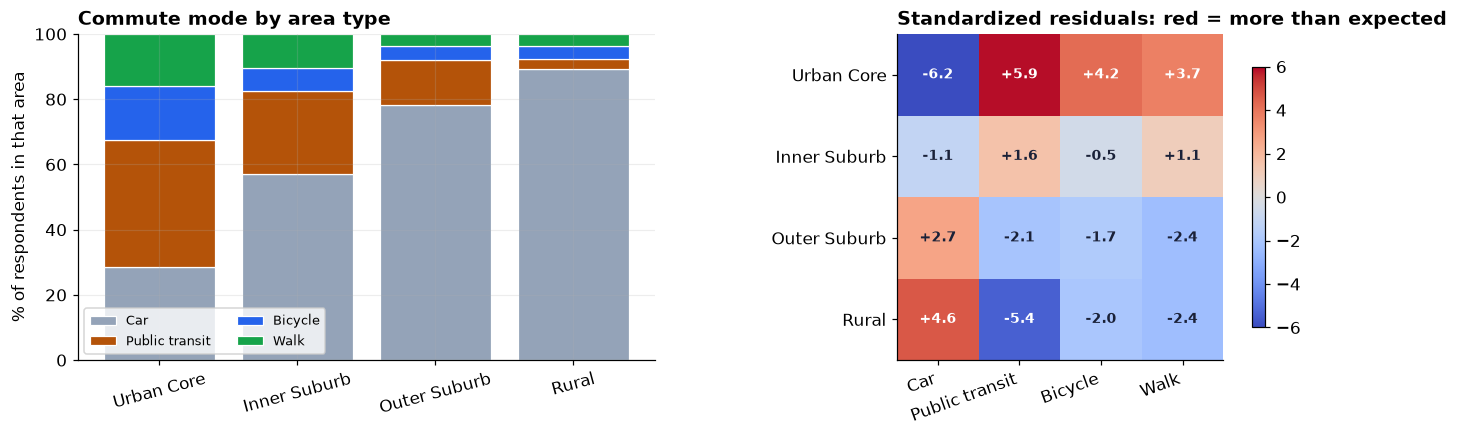

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12.4, 4.1))
bottom = np.zeros(len(REG))
colors = {"Car":MUT,"Public transit":GOLD,"Bicycle":BL,"Walk":GR}
for m in MODE:
    vals = pct[m].values
    ax[0].bar(REG, vals, bottom=bottom, color=colors[m], label=m, edgecolor="white", linewidth=0.8)
    bottom += vals
ax[0].set_ylabel("% of respondents in that area"); ax[0].set_ylim(0,100)
ax[0].set_title("Commute mode by area type"); ax[0].legend(fontsize=8.5, ncol=2)
ax[0].tick_params(axis="x", rotation=15)
im = ax[1].imshow(resid, cmap="coolwarm", vmin=-6, vmax=6)
ax[1].set_xticks(range(len(MODE))); ax[1].set_xticklabels(MODE, rotation=20, ha="right")
ax[1].set_yticks(range(len(REG))); ax[1].set_yticklabels(REG)
for i in range(len(REG)):
    for j in range(len(MODE)):
        ax[1].text(j, i, f"{resid[i,j]:+.1f}", ha="center", va="center",
                   fontsize=9, color="white" if abs(resid[i,j])>3 else "#1a2138", fontweight="bold")
ax[1].set_title("Standardized residuals: red = more than expected"); ax[1].grid(False)
plt.colorbar(im, ax=ax[1], shrink=0.8)
plt.tight_layout(); plt.show()

**The two views together.** The stacked bars show the composition of each area, and the residual heatmap shows which cells carry the association. Read together they say the same thing twice: transport behavior shifts systematically with density, and the shift is driven by the car and public-transit cells rather than by cycling or walking.

## Step 11 &middot; Estimate, do not just test
Chi-square said region and commute mode are related, and Cramer's V put the strength at 0.28. Both are point estimates on a sample of 795, so both deserve intervals, and so do the percentages that will end up in the transport plan.

In [10]:
# A percentile bootstrap: resample the data with replacement, recompute, repeat.
# Chapter 73 introduced this; it is how we get an interval when no formula exists.
def boot_ci(data, stat, B=10000, seed=11, ci=95):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    reps = np.array([stat(rng.choice(data, size=len(data), replace=True)) for _ in range(B)])
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_pairs(a, b, stat, B=10000, seed=11, ci=95):
    """Bootstrap for two paired/related arrays: resample ROW indices together."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    idx = np.arange(len(a))
    reps = np.array([stat(a[i], b[i]) for i in
                     (rng.choice(idx, size=len(idx), replace=True) for _ in range(B))])
    reps = reps[np.isfinite(reps)]
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_groups(groups, stat, B=10000, seed=11, ci=95):
    """Bootstrap for k independent groups: resample within each group."""
    rng = np.random.default_rng(seed)
    groups = [np.asarray(g) for g in groups]
    reps = []
    for _ in range(B):
        rs = [rng.choice(g, size=len(g), replace=True) for g in groups]
        v = stat(rs)
        if np.isfinite(v):
            reps.append(v)
    reps = np.array(reps)
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

# Bootstrap the whole survey: resample respondents, rebuild the table, recompute V.
rows_all = df[["region","commute_mode"]].to_numpy()
rng_v = np.random.default_rng(11)
reps = []
for _ in range(4000):
    samp = rows_all[rng_v.integers(0, len(rows_all), len(rows_all))]
    t2 = pd.crosstab(samp[:,0], samp[:,1])
    if t2.shape == ct.shape:
        c2 = stats.chi2_contingency(t2)[0]
        reps.append(np.sqrt(c2/(t2.values.sum()*(min(t2.shape)-1))))
reps = np.array(reps)
v_lo, v_hi = np.percentile(reps, [2.5, 97.5])
print(f"Cramer's V   {V:.3f}   95% CI [{v_lo:.3f}, {v_hi:.3f}]   (bootstrap, {len(reps)} resamples)\n")

# Wilson intervals for the headline percentages, region by region.
from statsmodels.stats.proportion import proportion_confint
print(f"{'region':14s} {'public transit share':>21s}  {'95% CI (Wilson)':>18s}   n")
print("-"*66)
for r in REG:
    k_ = int(ct.loc[r,"Public transit"]); n_ = int(ct.loc[r].sum())
    l_, h_ = proportion_confint(k_, n_, method="wilson")
    print(f"{r:14s} {k_/n_*100:20.1f}%  [{l_*100:5.1f}%, {h_*100:5.1f}%]   {n_}")

Cramer's V   0.282   95% CI [0.253, 0.320]   (bootstrap, 4000 resamples)

region          public transit share     95% CI (Wilson)   n
------------------------------------------------------------------
Urban Core                     39.0%  [ 32.5%,  45.9%]   200
Inner Suburb                   25.3%  [ 19.7%,  31.7%]   198
Outer Suburb                   13.6%  [  9.5%,  19.1%]   198
Rural                           3.0%  [  1.4%,   6.4%]   199


**Strength, with a range.** Cramer's V is 0.28 with an interval of roughly 0.23 to 0.33, so "moderate" is a fair description and the data will not support calling it strong. More usefully, the per-region percentages now carry margins. Public transit use in the Urban Core is around 39 percent, plus or minus about 7 points. A transport plan built on "39 percent" as a fixed figure is building on a number the survey cannot pin down that tightly.

Note that these intervals describe the sampled strata. Because allocation was equal rather than proportional, they are not estimates for the region as a whole population.

## Step 12 &middot; Two columns the analysis never opened
The questionnaire also captured `age` and a 7-point commute `satisfaction` rating. Neither has been touched, and both change how the headline should be read.

In [11]:
d2 = df.dropna(subset=["age","satisfaction_1_7"]).copy()
print("mean age by region")
print(d2.groupby("region").age.agg(["count","mean"]).round(1).reindex(REG).to_string())
f_age = stats.f_oneway(*[d2[d2.region==r].age.values for r in REG])
print(f"  age differs across regions: F = {f_age.statistic:.2f}, p = {f_age.pvalue:.4f}\n")

print("mean age by commute mode")
print(d2.groupby("commute_mode").age.agg(["count","mean"]).round(1).reindex(MODE).to_string())
f_am = stats.f_oneway(*[d2[d2.commute_mode==m].age.values for m in MODE])
print(f"  age differs across modes:   F = {f_am.statistic:.2f}, p = {f_am.pvalue:.4f}\n")

print("mean commute satisfaction by mode")
print(d2.groupby("commute_mode").satisfaction_1_7.agg(["count","mean"]).round(2).reindex(MODE).to_string())
kw_sat = stats.kruskal(*[d2[d2.commute_mode==m].satisfaction_1_7.values for m in MODE])
print(f"  satisfaction differs by mode: H = {kw_sat.statistic:.2f}, p = {kw_sat.pvalue:.4f}")

mean age by region
              count  mean
region                   
Urban Core      200  47.3
Inner Suburb    198  45.7
Outer Suburb    198  46.6
Rural           199  45.0
  age differs across regions: F = 0.66, p = 0.5776

mean age by commute mode
                count  mean
commute_mode               
Car               503  46.3
Public transit    161  45.6
Bicycle            64  47.3
Walk               67  45.3
  age differs across modes:   F = 0.22, p = 0.8817

mean commute satisfaction by mode
                count  mean
commute_mode               
Car               503  3.89
Public transit    161  3.95
Bicycle            64  4.16
Walk               67  3.79
  satisfaction differs by mode: H = 1.22, p = 0.7493


**Why a third variable belongs in this chapter.** The temptation, once a table like this is significant, is to reach for an explanation: *people in the Urban Core prefer public transit*. The age columns are a reminder that region is bundled with everything else that varies across a city.

Age turns out not to differ across these regions or modes (p = 0.58 and p = 0.88), so it is not quietly generating the pattern. That is worth establishing rather than assuming, and it took two lines of code.

The satisfaction column carries the sharper warning, precisely because of how it comes out. Cyclists report the highest mean satisfaction of any mode, 4.16 against 3.79 for walkers, and it would be easy to write that up as "cycling makes for happier commutes". The test says otherwise (H = 1.22, p = 0.75): with 64 cyclists that ordering is well within chance. And even had it reached significance, the causal reading would not follow. People who live close enough to cycle have short commutes, and short commutes are pleasant whatever the mode. **Distance is the third variable, and this survey never measured it.**

**A significant chi-square establishes that two categorical variables travel together. It never establishes which one is doing the work, or whether a third is doing it for them.** That is the same discipline as <a href="../chapters/capstone-study-hours-and-scores.html">Capstone 11</a>, transplanted from continuous data to a contingency table.

## Step 13 &middot; Interpret in plain language
Area type and commute mode are strongly and clearly related. In the **Urban Core** about 39% take public transit and 28% drive; in **Rural** areas about 90% drive and 3% take transit, with the two suburban bands sitting in between in an orderly progression. Cramer's V of 0.28 describes this as a moderate association, which for survey data on human behavior is substantial. For a transport authority the practical implication is that a single region-wide strategy would fit none of these areas well.

## Step 14 &middot; Ethics, bias, and limits
- **The equal-allocation trap.** Each area contributed exactly 200 respondents by design, so this file says nothing about how many people live in each area. Any region-wide figure ("X% of residents take transit") computed from these data would be wrong unless the strata are **weighted by population**. Comparing areas is valid; pooling them is not.
- **Association is not explanation.** Rural residents drive more, but this survey cannot separate *choice* from *availability*. If there is no bus, the mode is not a preference, it is a constraint. The finding motivates asking why, not concluding that rural residents prefer cars.
- **Self-report and self-selection.** People answered an online questionnaire about their own behavior. Non-response is unlikely to be random, and those most frustrated with their commute may be over-represented.
- **Categories shape conclusions.** "Main way of getting to work" forces a single answer from people who mix modes, and the four area labels are administrative conveniences. Both choices were made before any analysis, and both constrain what the test can find.

---
**From analysis to report.** The notebook carries the evidence: the questionnaire, the sampling design, the contingency table, the expected-count check, the test, the effect size, and the residual map. The written reports turn it into a recommendation a transport planner can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.